In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Corrected path assuming the file is in the root of 'MyDrive'
df = pd.read_excel('/content/drive/MyDrive/Synthetic_school_data(1).xlsx')

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3000, 39)


,Student ID,School,Gender,Class level,Parental educational level,Week1_attendance,Week2_attendance,Week3_attendance,Week4_attendance,Week5_attendance,Week6_attendance,Week7_attendance,Week8_attendance,Week9_attendance,Week10_attendance,Week11_attendance,Week12_attendance,Week13_attendance,Week14_attendance,Semester 1 average,Semester 2 average,Semester difference,Household income level,Family dropout history,Child labor involvement,Travel time to school,Mode of transport,Teacher relationship quality,Peer relationship quality,Extra-curricular activities,Section,Household income level (standardized),Travel time to school (minutes),grade_number,stream_letter,subgroup,level_prefix,long_commute_flag,long_walk_flag
0,1,Weweso MA,Female,5B1,SHS,1.0,1.0,1.0,1.0,1.00,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,60.81,6.06,-54.75,1,Not sure,No,25 minutes,Walking,Good,Good,Passive screen time,Kofi Annan,Low,25.0,5.0,B,1.0,NaN,0,0
1,2,Weweso MA,Female,4B,SHS,1.0,0.2,1.0,1.0,1.00,1.0,1.0,1.0,0.0,1.0,0.8,0.8,0.2,1.0,52.27,75.82,23.55,2,Yes,Yes,30min,Public transport,Good,Poor,Sports,Kofi Annan,Average,30.0,4.0,B,NaN,NaN,0,0
2,3,Ayeduase RC,Male,JHS 1,Tertiary,1.0,1.0,1.0,1.0,1.00,1.0,0.2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,52.25,6.34,-45.91,2,Yes,Yes,30 Minutes,Walking,Average,Average,Arts & Performance,Kofi Annan,Average,30.0,1.0,NaN,NaN,JHS,0,0
3,4,Weweso MA,Male,JHS 1B2,Tertiary,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,0.0,1.0,1.0,0.8,0.2,1.0,52.78,3.17,-49.61,2,No,No,30mins,Walking,Good,Good,Arts & Performance,Kofi Annan,Average,30.0,1.0,B,2.0,JHS,0,0
4,5,Weweso MA,Male,4B1,SHS,1.0,1.0,1.0,1.0,0.25,1.0,1.0,1.0,1.0,1.0,0.8,1.0,1.0,1.0,52.48,83.59,31.11,2,No,Sometimes,20 minutes,Public transport,Average,Poor,Sports,Kwame Nkrumah,Average,20.0,4.0,B,1.0,NaN,0,0


In [5]:
print("Shape before:", df.shape)
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

print(df.isnull().sum()[df.isnull().sum() > 0])

Shape before: (3000, 39)
Shape after dedup: (3000, 39)
Class level                      12
Extra-curricular activities     168
stream_letter                  1134
subgroup                       2109
level_prefix                   2316
dtype: int64


In [6]:
# stream_letter / subgroup / level_prefix are NaN because they don't apply to every
# class level (e.g. JHS classes have no A/B stream letter) - this is STRUCTURAL, not
# random missingness, so we fill with an explicit "not applicable" value rather than
# a statistical mode/mean.
df["stream_letter"] = df["stream_letter"].fillna("None")
df["subgroup"] = df["subgroup"].fillna(0)
df["level_prefix"] = df["level_prefix"].fillna("Primary")

# Extra-curricular activities: genuine missing survey response -> explicit "Unknown" category
df["Extra-curricular activities"] = df["Extra-curricular activities"].fillna("Unknown")

# Class level: small number of missing rows (~12) - drop rather than impute a
# structural/categorical field this important
df = df.dropna(subset=["Class level"]).reset_index(drop=True)

print("Remaining missing values:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Remaining missing values: 0
Shape after cleaning: (2988, 39)


In [7]:
columns_to_check = [
    "Parental educational level",
    "Household income level",
    "Family dropout history",
    "Child labor involvement",
    "Teacher relationship quality",
    "Peer relationship quality",
    "Extra-curricular activities",
    "Mode of transport"
]

for col in columns_to_check:
    print("=" * 60)
    print(col)
    print(df[col].value_counts(dropna=False).sort_index())
    print()

Parental educational level
Parental educational level
JHS          619
SHS          997
Tertiary    1372
Name: count, dtype: int64

Household income level
Household income level
1     406
2    1350
3    1232
Name: count, dtype: int64

Family dropout history
Family dropout history
No          1576
Not sure     652
Yes          760
Name: count, dtype: int64

Child labor involvement
Child labor involvement
No           1304
Sometimes     645
Yes          1039
Name: count, dtype: int64

Teacher relationship quality
Teacher relationship quality
Average     772
Good       1674
Poor        542
Name: count, dtype: int64

Peer relationship quality
Peer relationship quality
Average     645
Good       1744
Poor        599
Name: count, dtype: int64

Extra-curricular activities
Extra-curricular activities
Academic/Clubs          627
Arts & Performance     1406
Chores/Duties            36
Passive screen time     136
Sports                  616
Unknown                 167
Name: count, dtype: int64

M

In [8]:
df_proxy = df.copy()

# -------------------------
# Academic
# -------------------------
academic_raw = (df_proxy["Semester 1 average"] + df_proxy["Semester 2 average"]) / 2

# -------------------------
# Attendance
# -------------------------
attendance_cols = [f"Week{i}_attendance" for i in range(1, 15)]
attendance_raw = 1 - df_proxy[attendance_cols].mean(axis=1)

# -------------------------
# Ordinal risk maps (higher = higher risk)
# -------------------------
parent_map    = {"Tertiary": 0, "SHS": 1, "JHS": 2}
income_map    = {1: 0, 2: 1, 3: 2}                       # 1=High,2=Medium,3=Low
dropout_map   = {"No": 0, "Not sure": 1, "Yes": 2}
child_map     = {"No": 0, "Sometimes": 1, "Yes": 2}
teacher_map   = {"Good": 0, "Average": 1, "Poor": 2}
peer_map      = {"Good": 0, "Average": 1, "Poor": 2}
activity_map  = {"Sports": 0, "Academic/Clubs": 0, "Arts & Performance": 1,
                  "Passive screen time": 2, "Chores/Duties": 2, "Unknown": 1}
transport_map = {"Private transport": 0, "Public transport": 1, "Walking": 2}

# -------------------------
# Socioeconomic
# -------------------------
socioeconomic_raw = (
    df_proxy["Household income level"].map(income_map)
    + df_proxy["Parental educational level"].map(parent_map)
    + df_proxy["Family dropout history"].map(dropout_map)
    + df_proxy["Child labor involvement"].map(child_map)
) / 4

# -------------------------
# Engagement
# -------------------------
engagement_raw = (
    df_proxy["Teacher relationship quality"].map(teacher_map)
    + df_proxy["Peer relationship quality"].map(peer_map)
    + df_proxy["Extra-curricular activities"].map(activity_map)
) / 3

# -------------------------
# Accessibility
# -------------------------
accessibility_raw = (
    df_proxy["Mode of transport"].map(transport_map)
    + df_proxy["long_walk_flag"]
    + df_proxy["long_commute_flag"]
) / 3

assert not academic_raw.isnull().any()
assert not attendance_raw.isnull().any()
assert not socioeconomic_raw.isnull().any()
assert not engagement_raw.isnull().any()
assert not accessibility_raw.isnull().any()
print("All domain inputs mapped cleanly, no NaNs.")

All domain inputs mapped cleanly, no NaNs.


In [9]:
scaler = MinMaxScaler()

df_proxy["academic_domain"] = scaler.fit_transform(academic_raw.values.reshape(-1, 1))
df_proxy["academic_domain"] = 1 - df_proxy["academic_domain"]   # high grades = LOW risk

df_proxy["attendance_domain"]    = scaler.fit_transform(attendance_raw.values.reshape(-1, 1))
df_proxy["socioeconomic_domain"] = scaler.fit_transform(socioeconomic_raw.values.reshape(-1, 1))
df_proxy["engagement_domain"]    = scaler.fit_transform(engagement_raw.values.reshape(-1, 1))
df_proxy["accessibility_domain"] = scaler.fit_transform(accessibility_raw.values.reshape(-1, 1))

df_proxy[["academic_domain","attendance_domain","socioeconomic_domain",
          "engagement_domain","accessibility_domain"]].describe()

,academic_domain,attendance_domain,socioeconomic_domain,engagement_domain,accessibility_domain
count,2.988000e+03,2988.000000,2988.000000,2988.000000,2988.000000
mean,5.396872e-01,0.259890,0.457831,0.313253,0.310074
std,1.951122e-01,0.162609,0.200330,0.207740,0.184422
min,1.110223e-16,0.000000,0.000000,0.000000,0.000000
25%,3.642872e-01,0.147287,0.375000,0.166667,0.250000
50%,5.147654e-01,0.240310,0.500000,0.333333,0.250000
75%,7.340655e-01,0.356589,0.625000,0.500000,0.500000
max,1.000000e+00,1.000000,1.000000,1.000000,1.000000


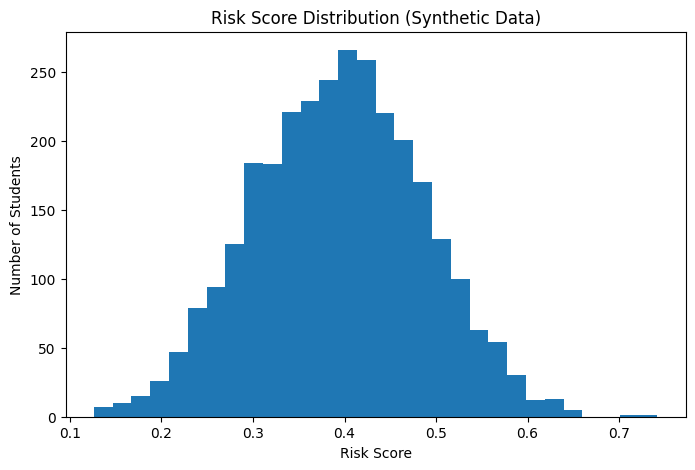

In [10]:
df_proxy["risk_score"] = (
      0.30 * df_proxy["academic_domain"]
    + 0.30 * df_proxy["attendance_domain"]
    + 0.20 * df_proxy["socioeconomic_domain"]
    + 0.10 * df_proxy["engagement_domain"]
    + 0.10 * df_proxy["accessibility_domain"]
)

plt.figure(figsize=(8,5))
plt.hist(df_proxy["risk_score"], bins=30)
plt.title("Risk Score Distribution (Synthetic Data)")
plt.xlabel("Risk Score")
plt.ylabel("Number of Students")
plt.show()

In [11]:
# ============================================================
# GENERATE NOISY DROPOUT RISK
# ============================================================

import numpy as np

np.random.seed(42)

# Add moderate noise to the latent risk score
noise = np.random.normal(
    loc=0,
    scale=0.20,
    size=len(df_proxy)
)

df_proxy["risk_score_noisy"] = (
    df_proxy["risk_score"] + noise
)


# ============================================================
# CREATE 3 DROPOUT-RISK CLASSES
# ============================================================

q1 = df_proxy["risk_score_noisy"].quantile(0.25)
q3 = df_proxy["risk_score_noisy"].quantile(0.75)

conditions = [
    df_proxy["risk_score_noisy"] <= q1,

    (df_proxy["risk_score_noisy"] > q1) &
    (df_proxy["risk_score_noisy"] < q3),

    df_proxy["risk_score_noisy"] >= q3
]

choices = [0, 1, 2]

df_proxy["dropout_risk"] = np.select(
    conditions,
    choices
)

print("Class distribution:")
print(
    df_proxy["dropout_risk"]
    .value_counts()
    .sort_index()
)

Class distribution:
dropout_risk
0     747
1    1494
2     747
Name: count, dtype: int64


In [12]:
print(df_proxy[[
    "risk_score",
    "risk_score_noisy",
    "dropout_risk"
]].head(10))

print("\nClass proportions:")
print(
    df_proxy["dropout_risk"]
    .value_counts(normalize=True)
    .sort_index()
)

   risk_score  risk_score_noisy  dropout_risk
0    0.432673          0.532015             1
1    0.457679          0.430026             1
2    0.481578          0.611115             2
3    0.408220          0.712826             2
4    0.291417          0.244586             0
5    0.434942          0.388115             1
6    0.288896          0.604738             2
7    0.479793          0.633280             2
8    0.335073          0.241178             0
9    0.534261          0.642773             2

Class proportions:
dropout_risk
0    0.25
1    0.50
2    0.25
Name: proportion, dtype: float64


In [ ]:
leak_cols = [
    "academic_domain", "attendance_domain", "socioeconomic_domain",
    "engagement_domain", "accessibility_domain", "risk_score"
]

id_cols = ["Student ID", "School", "Class level", "Section"]   # keep for graph building, not as raw model input
target_col = "dropout_risk"

raw_categorical = [
    "Gender", "Parental educational level", "Family dropout history",
    "Child labor involvement", "Mode of transport", "Teacher relationship quality",
    "Peer relationship quality", "Extra-curricular activities", "stream_letter",
    "level_prefix", "Household income level (standardized)"
]

raw_numeric = attendance_cols + [
    "Semester 1 average", "Semester 2 average", "Semester difference",
    "Household income level", "Travel time to school (minutes)",
    "grade_number", "subgroup", "long_commute_flag", "long_walk_flag"
]

df_model = df_proxy.drop(columns=leak_cols)

X_cat = pd.get_dummies(df_model[raw_categorical], drop_first=False)
X_num = df_model[raw_numeric]
X = pd.concat([X_num, X_cat], axis=1)
y = df_model[target_col]

print("X shape:", X.shape, "| y shape:", y.shape)
X.head()

X shape: (2988, 57) | y shape: (2988,)


,Week1_attendance,Week2_attendance,Week3_attendance,Week4_attendance,Week5_attendance,Week6_attendance,Week7_attendance,Week8_attendance,Week9_attendance,Week10_attendance,Week11_attendance,Week12_attendance,Week13_attendance,Week14_attendance,Semester 1 average,Semester 2 average,Semester difference,Household income level,Travel time to school (minutes),grade_number,subgroup,long_commute_flag,long_walk_flag,Gender_Female,Gender_Male,Parental educational level_JHS,Parental educational level_SHS,Parental educational level_Tertiary,Family dropout history_No,Family dropout history_Not sure,Family dropout history_Yes,Child labor involvement_No,Child labor involvement_Sometimes,Child labor involvement_Yes,Mode of transport_Private transport,Mode of transport_Public transport,Mode of transport_Walking,Teacher relationship quality_Average,Teacher relationship quality_Good,Teacher relationship quality_Poor,Peer relationship quality_Average,Peer relationship quality_Good,Peer relationship quality_Poor,Extra-curricular activities_Academic/Clubs,Extra-curricular activities_Arts & Performance,Extra-curricular activities_Chores/Duties,Extra-curricular activities_Passive screen time,Extra-curricular activities_Sports,Extra-curricular activities_Unknown,stream_letter_A,stream_letter_B,stream_letter_None,level_prefix_JHS,level_prefix_Primary,Household income level (standardized)_Average,Household income level (standardized)_High,Household income level (standardized)_Low
0,1.0,1.0,1.0,1.0,1.00,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,60.81,6.06,-54.75,1,25.0,5.0,1.0,0,0,True,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,True
1,1.0,0.2,1.0,1.0,1.00,1.0,1.0,1.0,0.0,1.0,0.8,0.8,0.2,1.0,52.27,75.82,23.55,2,30.0,4.0,0.0,0,0,True,False,False,True,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,True,False,False
2,1.0,1.0,1.0,1.0,1.00,1.0,0.2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,52.25,6.34,-45.91,2,30.0,1.0,0.0,0,0,False,True,False,False,True,False,False,True,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False
3,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,0.0,1.0,1.0,0.8,0.2,1.0,52.78,3.17,-49.61,2,30.0,1.0,2.0,0,0,False,True,False,False,True,True,False,False,True,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,True,False,False
4,1.0,1.0,1.0,1.0,0.25,1.0,1.0,1.0,1.0,1.0,0.8,1.0,1.0,1.0,52.48,83.59,31.11,2,20.0,4.0,1.0,0,0,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,True,False,False


In [ ]:
df_proxy.to_csv("Featured_Synthetic_school_data_with_proxy.csv", index=False)   # full table incl. domains + label, for graph building
X.to_csv("Synthetic_X_features.csv", index=False)                       # leakage-free model feature matrix
y.to_csv("Synthetic_y_labels.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
from google.colab import files

files.download("Featured_Synthetic_school_data_with_proxy.csv")
files.download("Synthetic_X_features.csv")
files.download("Synthetic_y_labels.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>